# Domain Expansion Detector — Hand Gesture Classifier

In [26]:
import os
import glob
import math
import numpy as np
import cv2
import matplotlib.pyplot as plt

DATASET_DIR = "dataset"
CLASS_NAMES = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])
CLASS_NAMES

['Chimera Shadow Garden',
 'Idle Death Gamble',
 'Malevolent Shrine',
 'Self-Embodiment of Perfection_Upper',
 'Unlimited Void',
 'Womb Profusion']

## Background Subtraction on dataset

In [27]:
# Isolate the hand(s) using color segmentation, then render as grayscale on a white background.

def _hand_mask(bgr):
    blurred = cv2.GaussianBlur(bgr, (5, 5), 0)

    hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
    hsv_mask = cv2.inRange(hsv, (0, 30, 60), (20, 150, 255))

    ycrcb = cv2.cvtColor(blurred, cv2.COLOR_BGR2YCrCb)
    ycrcb_mask = cv2.inRange(ycrcb, (0, 135, 85), (255, 180, 135))

    mask = cv2.bitwise_and(hsv_mask, ycrcb_mask)

    # Close gaps then drop speckle using morphology.
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)

    # Keep components large enough to be a hand — drops stray skin-colored specks
    num, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num <= 1:
        return mask
    areas = stats[1:, cv2.CC_STAT_AREA]
    largest = int(areas.max())
    keep = np.zeros_like(mask)
    for i, area in enumerate(areas, start=1):
        if area >= max(largest * 0.2, 0.01 * mask.size):
            keep[labels == i] = 255
    return keep


def subtract_background(bgr):
    mask = _hand_mask(bgr)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    result = np.full_like(gray, 255)
    result[mask == 255] = gray[mask == 255]
    return result


def to_mask(bg_subtracted):
    return (bg_subtracted != 255).astype(np.uint8) * 255


def subtract_background_folder(input_dir, output_dir, pattern="*.jpg", recursive=True):
    os.makedirs(output_dir, exist_ok=True)
    glob_pattern = os.path.join(input_dir, "**", pattern) if recursive else os.path.join(input_dir, pattern)
    count = 0
    for image_path in glob.glob(glob_pattern, recursive=recursive):
        image = cv2.imread(image_path)
        if image is None:
            continue
        rel = os.path.relpath(image_path, input_dir)
        out_path = os.path.join(output_dir, rel)
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        cv2.imwrite(out_path, subtract_background(image))
        count += 1
    return count


subtract_background_folder(DATASET_DIR, "dataset_bg_subtracted")

119

## Load image

In [28]:
def load_image(path, max_side=512):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    h, w = img.shape[:2]
    scale = max_side / float(max(h, w))
    if scale < 1.0:
        img = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
    return img

## Canny edge detection

In [29]:
def canny_edges(mask):
    return cv2.Canny(mask, 100, 200)

## Contour extraction

In [30]:
def largest_contour(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    return max(contours, key=cv2.contourArea)

## Hu moments

In [31]:
def hu_moments(contour):
    M = cv2.moments(contour)
    hu = cv2.HuMoments(M).flatten()
    # Log-transform: standard normalization so all 7 values have comparable magnitude
    return -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)

## Combine to Detect Gesture

In [32]:
def process(path):
    bgr = load_image(path)
    bg_subtracted = subtract_background(bgr)
    mask = to_mask(bg_subtracted)
    edges = canny_edges(mask)
    contour = largest_contour(mask)
    if contour is None:
        return {"bgr": bgr, "mask": mask, "edges": edges, "contour": None, "hu": None}
    return {
        "bgr": bgr,
        "mask": mask,
        "edges": edges,
        "contour": contour,
        "hu": hu_moments(contour),
    }

## 7. Build reference dataset & classify

For each class folder, compute contours for every image and store them. At query time, use `cv2.matchShapes` (which uses log-Hu moments internally, method I2) against every reference and take the class of the nearest match.

## Build Reference Dataset

In [33]:
def build_reference(dataset_dir):
    """Compute log-Hu moment vectors for every image in each class folder."""
    reference = {name: [] for name in CLASS_NAMES}
    for class_name in CLASS_NAMES:
        class_dir = os.path.join(dataset_dir, class_name)
        for img_path in glob.glob(os.path.join(class_dir, "*.jpg")):
            result = process(img_path)
            if result["hu"] is not None:
                reference[class_name].append(result["hu"])
        print(f"{class_name}: {len(reference[class_name])} vectors")
    return reference

reference = build_reference(DATASET_DIR)

Chimera Shadow Garden: 20 vectors
Idle Death Gamble: 20 vectors
Malevolent Shrine: 20 vectors
Self-Embodiment of Perfection_Upper: 20 vectors
Unlimited Void: 19 vectors
Womb Profusion: 20 vectors


## Classifier — Nearest Neighbour by Euclidean Distance

In [34]:
def classify(hu_vec, reference):
    """
    1-NN classifier. Returns predicted class, its distance, and per-class
    minimum distances (used to build the confidence matrix).
    """
    best_class, best_dist = None, float("inf")
    per_class_dist = {}
    for class_name, vectors in reference.items():
        if not vectors:
            per_class_dist[class_name] = float("inf")
            continue
        d = min(np.linalg.norm(hu_vec - v) for v in vectors)
        per_class_dist[class_name] = d
        if d < best_dist:
            best_dist, best_class = d, class_name
    return best_class, best_dist, per_class_dist

## Evaluate on Test Set

In [35]:
TEST_LABELS = {
    "test_set/test1.jpg": "Unlimited Void",
    "test_set/test2.jpg": "Malevolent Shrine",
    "test_set/test3.jpg": "Chimera Shadow Garden",
    "test_set/test4.jpg": "Idle Death Gamble",
    "test_set/test5.jpg": "Self-Embodiment of Perfection_Upper",
    "test_set/test6.jpg": "Womb Profusion",
}

results = []
for path, true_label in TEST_LABELS.items():
    r = process(path)
    if r["hu"] is None:
        pred, dist, per_class = "UNKNOWN", float("inf"), {}
    else:
        pred, dist, per_class = classify(r["hu"], reference)
    correct = pred == true_label
    results.append({"path": path, "true": true_label, "pred": pred,
                    "correct": correct, "per_class": per_class})
    mark = "V" if correct else "X"
    print(f"[{mark}] {path}  true={true_label}  pred={pred}  dist={dist:.4f}")

accuracy = sum(r["correct"] for r in results) / len(results)
print(f"Accuracy: {sum(r['correct'] for r in results)}/{len(results)} ({accuracy*100:.0f}%)")

[X] test_set/test1.jpg  true=Unlimited Void  pred=Womb Profusion  dist=0.7898
[X] test_set/test2.jpg  true=Malevolent Shrine  pred=Chimera Shadow Garden  dist=1.1018
[V] test_set/test3.jpg  true=Chimera Shadow Garden  pred=Chimera Shadow Garden  dist=1.5904
[X] test_set/test4.jpg  true=Idle Death Gamble  pred=Malevolent Shrine  dist=0.8108
[V] test_set/test5.jpg  true=Self-Embodiment of Perfection_Upper  pred=Self-Embodiment of Perfection_Upper  dist=0.1847
[V] test_set/test6.jpg  true=Womb Profusion  pred=Womb Profusion  dist=1.5764
Accuracy: 3/6 (50%)


## Confidence Matrix

Each cell shows the minimum Euclidean distance between the test image (row) and the nearest reference image in that class (column). Lower = more similar. The predicted class is the column with the lowest value per row.

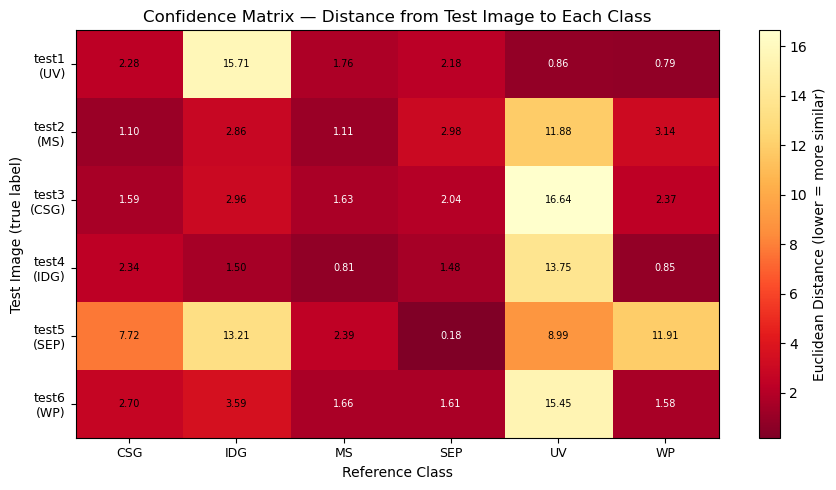

In [36]:
short_names = {
    "Chimera Shadow Garden": "CSG",
    "Idle Death Gamble": "IDG",
    "Malevolent Shrine": "MS",
    "Self-Embodiment of Perfection_Upper": "SEP",
    "Unlimited Void": "UV",
    "Womb Profusion": "WP",
}

row_labels = [f"test{i+1}\n({short_names.get(r['true'], r['true'])})" for i, r in enumerate(results)]
col_labels = [short_names.get(c, c) for c in CLASS_NAMES]

dist_matrix = np.array([
    [r["per_class"].get(c, float("inf")) for c in CLASS_NAMES]
    for r in results
])

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(dist_matrix, cmap="YlOrRd_r", aspect="auto")
plt.colorbar(im, ax=ax, label="Euclidean Distance (lower = more similar)")

ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(col_labels, fontsize=9)
ax.set_yticks(range(len(results)))
ax.set_yticklabels(row_labels, fontsize=9)
ax.set_title("Confidence Matrix — Distance from Test Image to Each Class")
ax.set_xlabel("Reference Class")
ax.set_ylabel("Test Image (true label)")

for i in range(len(results)):
    for j in range(len(CLASS_NAMES)):
        val = dist_matrix[i, j]
        txt = f"{val:.2f}" if val != float("inf") else "inf"
        color = "white" if val < dist_matrix[i].min() * 1.3 else "black"
        ax.text(j, i, txt, ha="center", va="center", fontsize=7, color=color)

plt.tight_layout()
plt.show()

## Confusion Matrix

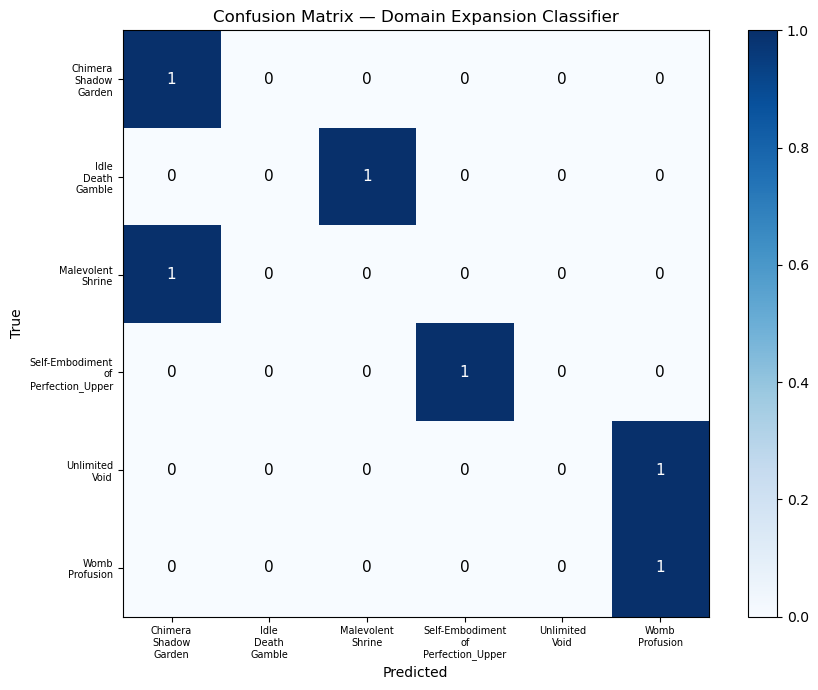

In [37]:
true_labels  = [r["true"] for r in results]
pred_labels  = [r["pred"] for r in results]

cm = np.zeros((len(CLASS_NAMES), len(CLASS_NAMES)), dtype=int)
label_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
for t, p in zip(true_labels, pred_labels):
    if t in label_idx and p in label_idx:
        cm[label_idx[t], label_idx[p]] += 1

col_labels_full = [c.replace(" ", "\n") for c in CLASS_NAMES]

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(col_labels_full, fontsize=7)
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_yticklabels(col_labels_full, fontsize=7)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Domain Expansion Classifier")

for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > 0 else "black", fontsize=11)

plt.tight_layout()
plt.show()